In [146]:
import numpy as np
import matplotlib.pyplot as plt

In [147]:
# Ασκηση 1. Θεωρήστε το πρόβλημα γραμμικού προγραμματισμού:
# max Z = 3x1 + x2
# όταν
# (Π1) 6x1 + 3x2 ≥ 12
# (Π2) 4x1 + 8x2 ≥ 16
# (Π3) 6x1 + 5x2 ≤ 30
# (Π4) 6x1 + 7x2 ≤ 36
# x1, x2 ≥ 0
# (α) Να παραστήσετε γραφικά την εφικτή περιοχή του προβλήματος καθώς και όλες τις
# κορυφές της. Περιγράψτε τη μορφή της εφικτής περιοχής. Με γραφικό τρόπο βρείτε
# τη βέλτιστη κορυφή του προβλήματος, εάν υπάρχει

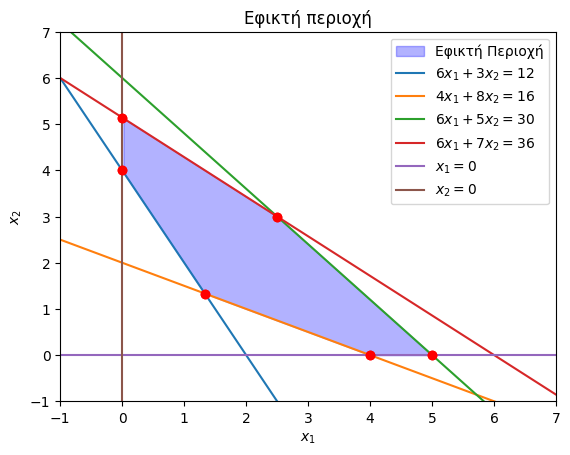

In [148]:
#line a1x1+a2x2=b

def x2(x1, line):
  a1,a2,b = line
  if a2!=0:
    return (b-a1*x1)/a2
  else:
    return -1

# Εύρεση κοινών κορυφών δύο ευθειών της μορφής
# a11x1+a12x2 = b1
# a21x1+a22x2 = b2

def vertex(*hyperplanes):
  A = []
  b = []
  for h in hyperplanes:
    A.append(h[:-1])
    b.append(h[-1])
  A = np.array(A)
  b = np.array(b)
  if np.linalg.det(A)!=0:
    v = tuple(np.linalg.solve(A, b))
    return v
  else:
    return -1



# Ορισμός ευθειών
x1 = np.linspace(-10, 10,500)

constraints_geq = ((6,3,12),
                   (4,8,16))
constraints_leq = ((6,5,30),
                   (6,7,36))
constraints_sign = ((1,0,0),
                    (0,1,0))

# sign constraints
min_x2 = np.zeros_like(x1)
min_x1 = np.zeros_like(x1)

x2_geq = [min_x2]
x2_leq = []
x1_geq = [min_x1]
x1_leq = []

for line in constraints_geq:
  x2_geq.append(x2(x1, line))

for line in constraints_leq:
  x2_leq.append(x2(x1,line))

where_condition = np.logical_and(np.minimum.reduce(x2_leq)>= np.maximum.reduce(x2_geq), x1 >= np.maximum.reduce(x1_geq))

plt.fill_between(x1,np.maximum.reduce(x2_geq), np.minimum.reduce(x2_leq), where=where_condition,
                 color='blue', alpha=0.3, label='Εφικτή Περιοχή')

plt.plot(x1, x2_geq[1], label='$6x_1 + 3x_2 = 12$')
plt.plot(x1, x2_geq[2], label='$4x_1 + 8x_2 = 16$')
plt.plot(x1, x2_leq[0], label='$6x_1 + 5x_2 = 30$')
plt.plot(x1, x2_leq[1], label='$6x_1 + 7x_2 = 36$')
plt.plot(x1, x2_geq[0], label='$x_1 = 0$')
plt.plot(x1_geq[0], x1, label='$x_2 = 0$')

vertexes_x=[]
vertexes_y=[]
for line1 in constraints_geq+constraints_leq+constraints_sign:
  for line2 in constraints_geq+constraints_leq+constraints_sign:
    v = vertex(line1,line2)
    if v!=-1:
      x, y = v
      #Κορυφές στην εφικτή περιοχή
      if (all(a * x + b * y >= c for a, b, c in constraints_geq+constraints_sign)
          and all(a * x + b * y <= c for a, b, c in constraints_leq)):

          vertexes_x.append(x)
          vertexes_y.append(y)

plt.scatter(vertexes_x, vertexes_y, color = 'red',  zorder=5)




# Προσαρμογές γραφήματος
plt.xlim(-1, 7)
plt.ylim(-1, 7)

plt.xlabel(r'$x_1$')
plt.ylabel(r'$x_2$')
plt.legend()
plt.title("Εφικτή περιοχή")
# Εμφάνιση γραφήματος
plt.show()


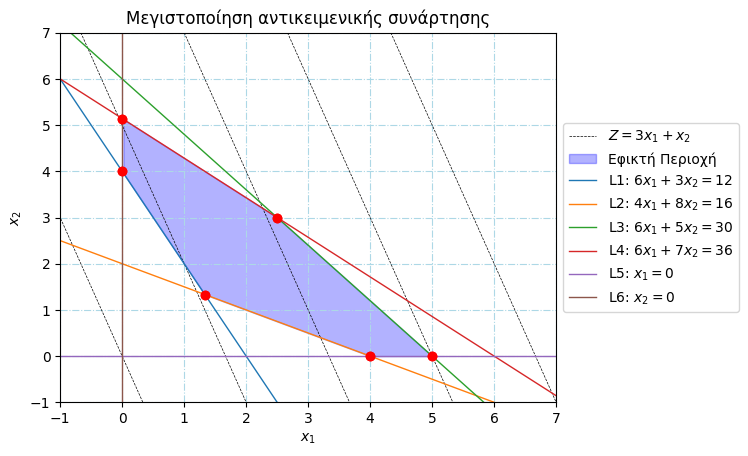

In [149]:
obj_values = np.linspace(0, 20, 5)
for z in obj_values:
  line=3,1,z
  if z==0:
    plt.plot(x1, x2(x1,line), '--', color = 'black', label='$Z = 3x_1 + x_2$', linewidth=0.5)
  else:
    plt.plot(x1, x2(x1,line), '--', color = 'black', linewidth=0.5)

where_condition = np.logical_and(np.minimum.reduce(x2_leq)>= np.maximum.reduce(x2_geq), x1 >= np.maximum.reduce(x1_geq))

plt.fill_between(x1,np.maximum.reduce(x2_geq), np.minimum.reduce(x2_leq), where=where_condition,
                 color='blue', alpha=0.3, label='Εφικτή Περιοχή')

plt.plot(x1, x2_geq[1],linewidth=1, label='L1: $6x_1 + 3x_2 = 12$')
plt.plot(x1, x2_geq[2],linewidth=1, label='L2: $4x_1 + 8x_2 = 16$')
plt.plot(x1, x2_leq[0],linewidth=1, label='L3: $6x_1 + 5x_2 = 30$')
plt.plot(x1, x2_leq[1],linewidth=1, label='L4: $6x_1 + 7x_2 = 36$')
plt.plot(x1, x2_geq[0],linewidth=1, label='L5: $x_1 = 0$')
plt.plot(x1_geq[0], x1,linewidth=1, label='L6: $x_2 = 0$')

vertexes_x=[]
vertexes_y=[]
for line1 in constraints_geq+constraints_leq+constraints_sign:
  for line2 in constraints_geq+constraints_leq+constraints_sign:
    v = vertex(line1,line2)
    if v!=-1:
      x, y = v
      #Κορυφές στην εφικτή περιοχή
      if (all(a * x + b * y >= c for a, b, c in constraints_geq+constraints_sign)
          and all(a * x + b * y <= c for a, b, c in constraints_leq)):

          vertexes_x.append(x)
          vertexes_y.append(y)

plt.scatter(vertexes_x, vertexes_y, color = 'red',  zorder=5)
# Προσαρμογές γραφήματος
plt.xlim(-1, 7)
plt.ylim(-1, 7)

plt.xlabel(r'$x_1$')
plt.ylabel(r'$x_2$')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=10)
plt.grid(True, linestyle='-.', color = 'lightblue')
plt.title("Μεγιστοποίηση αντικειμενικής συνάρτησης")
# Εμφάνιση γραφήματος
plt.show()

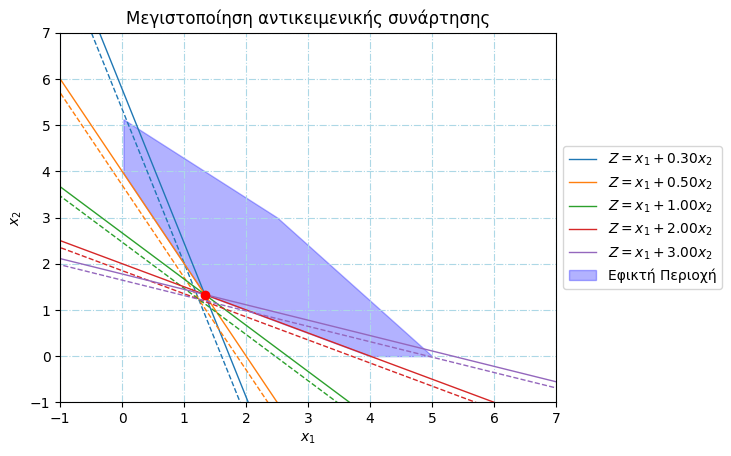

In [150]:
x0,y0 = vertex(constraints_geq[0], constraints_geq[1])
c2 = [0.3,0.5,1,2,3]
for c in c2:
  line = (1,c,0)
  plots  = plt.plot(x1+x0, x2(x1,line)+y0, label='$Z = x_1 + {:.2f}x_2$'.format(c), linewidth=1)
  plt.plot(x1+x0-0.1, x2(x1,line)+y0-0.1, '--', color = plots[0].get_color(), linewidth=1)

plt.fill_between(x1,np.maximum.reduce(x2_geq), np.minimum.reduce(x2_leq), where=where_condition,
                 color='blue', alpha=0.3, label='Εφικτή Περιοχή')


plt.scatter(x0, y0, color = 'red',  zorder=5)
# Προσαρμογές γραφήματος
plt.xlim(-1, 7)
plt.ylim(-1, 7)

plt.xlabel(r'$x_1$')
plt.ylabel(r'$x_2$')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=10)
plt.grid(True, linestyle='-.', color = 'lightblue')
plt.title("Μεγιστοποίηση αντικειμενικής συνάρτησης")
# Εμφάνιση γραφήματος
plt.show()

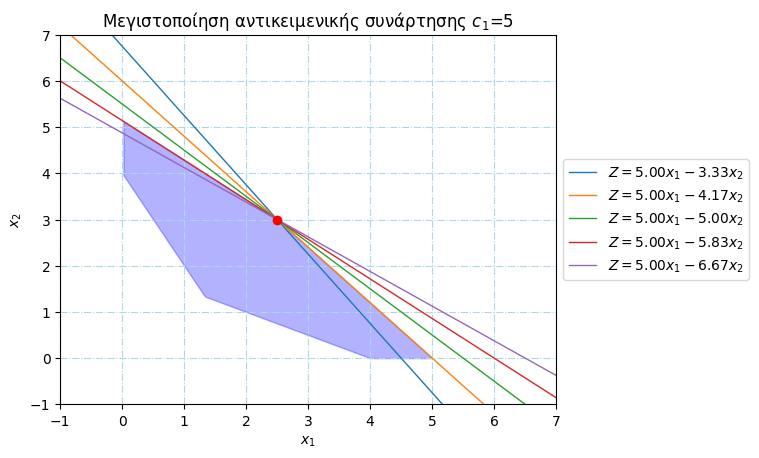

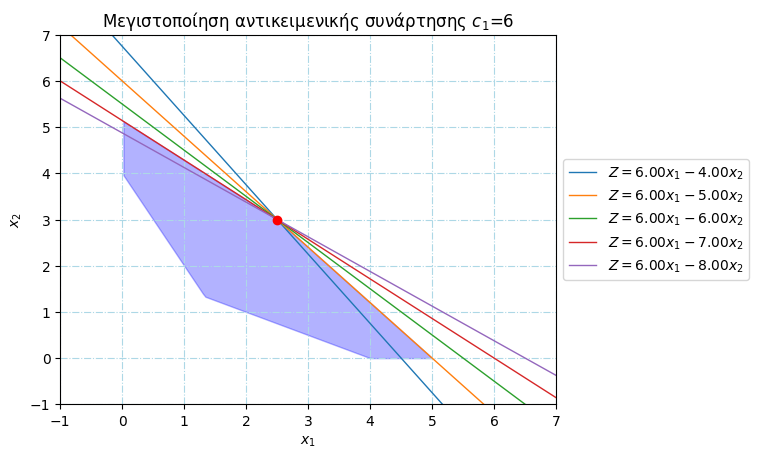

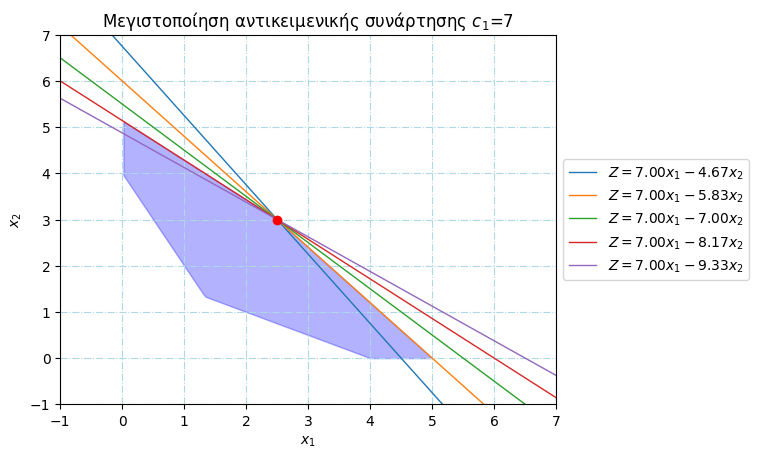

In [151]:
x0,y0 = vertex(constraints_leq[0], constraints_leq[1])

c1 = np.array([5,6,7])
c2 = np.linspace(4,8,5)

for c1p in c1:
  c2p=c2*c1p/6
  for c2pp in c2p:
    line = (c1p,c2pp, 0)
    plt.plot(x1+x0, x2(x1,line)+y0,  label='$Z = {:.2f}x_1 - {:.2f}x_2$'.format(c1p,c2pp), linewidth=1)

  plt.fill_between(x1,np.maximum.reduce(x2_geq), np.minimum.reduce(x2_leq), where=where_condition,
                  color='blue', alpha=0.3)#, label='Εφικτή Περιοχή')



  plt.scatter(x0, y0, color = 'red',  zorder=5)
  # Προσαρμογές γραφήματος
  plt.xlim(-1, 7)
  plt.ylim(-1, 7)

  plt.xlabel(r'$x_1$')
  plt.ylabel(r'$x_2$')
  plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=10)
  plt.grid(True, linestyle='-.', color = 'lightblue')
  plt.title("Μεγιστοποίηση αντικειμενικής συνάρτησης $c_1$={}".format(c1p))
  # Εμφάνιση γραφήματος
  plt.show()

In [8]:
#Άσκηση 2

In [152]:
#Έλεγχος περιορισμών
def check_constraints(x,geq,leq,eq,sign):
  x = np.array(x)
  for const in geq:
    if np.dot(np.array(const[:-1]),x)<const[-1]:
      #print(const)
      return False
  for const in leq:
    if np.dot(np.array(const[:-1]),x)>const[-1]:
      #print(const)
      return False
  for const in eq:
    if np.dot(np.array(const[:-1]),x)!=const[-1]:
      #print(const)
      return False
  for const in sign:
    if np.dot(np.array(const[:-1]),x)<0:
      #print(const)
      return False
  return True

6.0 6.0
7.5 4.5


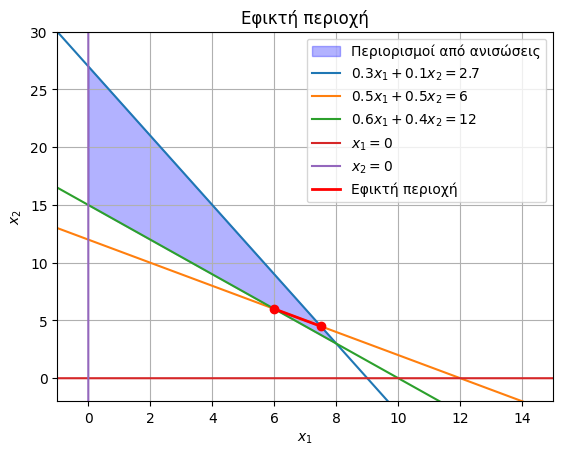

In [153]:

# Ορισμός ευθειών
x1 = np.linspace(-10, 50,100000)

constraints_leq2 = [(0.3,0.1,2.7)]
constraints_eq2 = [(0.5,0.5,6)]
constraints_geq2 = [(0.6,0.4,6)]
constraints_sign2 = [(1,0,0),
                    (0,1,0)]
# sign constraints
min_x2 = np.zeros_like(x1)
min_x1 = np.zeros_like(x1)

x2_geq2 = [min_x2]
x2_leq2 = []
x1_geq2 = [min_x1]
x1_leq2 = []
x2_eq2 = []

for line in constraints_geq2:
  x2_geq2.append(x2(x1, line))

for line in constraints_leq2:
  x2_leq2.append(x2(x1,line))

for line in constraints_eq2:
  x2_eq2.append(x2(x1,line))

where_condition2 = np.logical_and(np.minimum.reduce(x2_leq2)>= np.maximum.reduce(x2_geq2), x1 >= np.maximum.reduce(x1_geq2))

plt.fill_between(x1,np.maximum.reduce(x2_geq2), np.minimum.reduce(x2_leq2), where=where_condition2,
                 color='blue', alpha=0.3, label='Περιορισμοί από ανισώσεις')

plt.plot(x1, x2_leq2[0], label='$0.3x_1 + 0.1x_2 = 2.7$')
plt.plot(x1, x2_eq2[0], label='$0.5x_1 + 0.5x_2 = 6$')
plt.plot(x1, x2_geq2[1], label='$0.6x_1 + 0.4x_2 = 12$')
plt.plot(x1, x2_geq2[0], label='$x_1 = 0$')
plt.plot(x1_geq2[0], x1, label='$x_2 = 0$')

vertexes_x=[]
vertexes_y=[]

for line1 in constraints_geq2+constraints_leq2+constraints_sign2+constraints_eq2:
  for line2 in constraints_geq2+constraints_leq2+constraints_sign2+constraints_eq2:
    v = vertex(line1,line2)
    if v!=-1:
      x, y = v
      x=round(x,2)
      y=round(y,2)
      #Κορυφές στην εφικτή περιοχή
      if (all(a * x + b * y >= c for a, b, c in constraints_geq2+constraints_sign2)
          and all(a * x + b * y <= c for a, b, c in constraints_leq2)
          and all(a * x + b * y == c for a, b, c in constraints_eq2)
          and not (x in vertexes_x and y in vertexes_y)):

          vertexes_x.append(x)
          vertexes_y.append(y)
plt.scatter(vertexes_x, vertexes_y, color = 'red',  zorder=5)
plt.plot(vertexes_x, vertexes_y, 'red', linewidth=2, label="Εφικτή περιοχή")
for i in range(len(vertexes_x)):
  print(vertexes_x[i], vertexes_y[i])


# Προσαρμογές γραφήματος
plt.xlim(-1, 15)
plt.ylim(-2, 30)
plt.xlabel(r'$x_1$')
plt.ylabel(r'$x_2$')
plt.legend()
plt.title("Εφικτή περιοχή")
plt.grid(True)
# Εμφάνιση γραφήματος
plt.show()


[5.175 5.25  5.325 5.4   5.475]
6.0 6.0
7.5 4.5


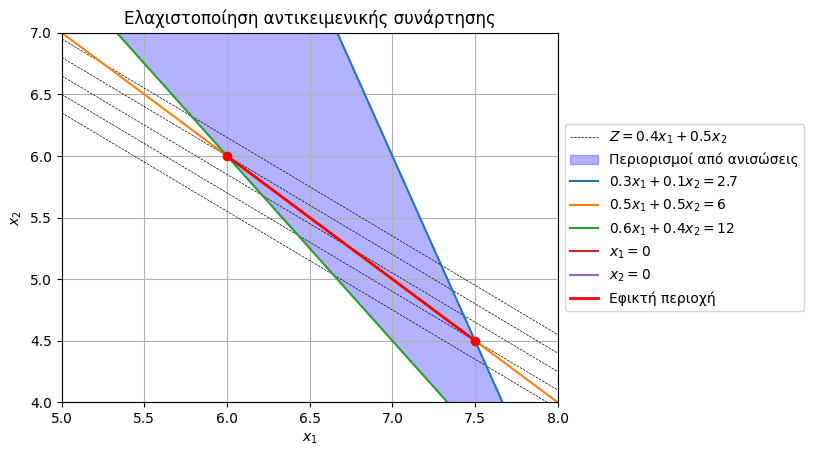

In [154]:
obj_values = np.linspace(5.175,5.475,5)
print(obj_values)
for z in obj_values:
  line=0.4,0.5,z
  if z==5.175:
    plt.plot(x1, x2(x1,line), '--', color = 'black', label='$Z = 0.4x_1 + 0.5x_2$', linewidth=0.5)
  else:
    plt.plot(x1, x2(x1,line), '--', color = 'black', linewidth=0.5)

# Ορισμός ευθειών
x1 = np.linspace(-10, 50,100000)

constraints_leq2 = [(0.3,0.1,2.7)]
constraints_eq2 = [(0.5,0.5,6)]
constraints_geq2 = [(0.6,0.4,6)]
constraints_sign2 = [(1,0,0),
                    (0,1,0)]
# sign constraints
min_x2 = np.zeros_like(x1)
min_x1 = np.zeros_like(x1)

x2_geq2 = [min_x2]
x2_leq2 = []
x1_geq2 = [min_x1]
x1_leq2 = []
x2_eq2 = []

for line in constraints_geq2:
  x2_geq2.append(x2(x1, line))

for line in constraints_leq2:
  x2_leq2.append(x2(x1,line))

for line in constraints_eq2:
  x2_eq2.append(x2(x1,line))

where_condition2 = np.logical_and(np.minimum.reduce(x2_leq2)>= np.maximum.reduce(x2_geq2), x1 >= np.maximum.reduce(x1_geq2))

plt.fill_between(x1,np.maximum.reduce(x2_geq2), np.minimum.reduce(x2_leq2), where=where_condition2,
                 color='blue', alpha=0.3, label='Περιορισμοί από ανισώσεις')

plt.plot(x1, x2_leq2[0], label='$0.3x_1 + 0.1x_2 = 2.7$')
plt.plot(x1, x2_eq2[0], label='$0.5x_1 + 0.5x_2 = 6$')
plt.plot(x1, x2_geq2[1], label='$0.6x_1 + 0.4x_2 = 12$')
plt.plot(x1, x2_geq2[0], label='$x_1 = 0$')
plt.plot(x1_geq2[0], x1, label='$x_2 = 0$')

vertexes_x=[]
vertexes_y=[]

for line1 in constraints_geq2+constraints_leq2+constraints_sign2+constraints_eq2:
  for line2 in constraints_geq2+constraints_leq2+constraints_sign2+constraints_eq2:
    v = vertex(line1,line2)
    if v!=-1:
      x, y = v
      x=round(x,2)
      y=round(y,2)
      #Κορυφές στην εφικτή περιοχή
      if (all(a * x + b * y >= c for a, b, c in constraints_geq2+constraints_sign2)
          and all(a * x + b * y <= c for a, b, c in constraints_leq2)
          and all(a * x + b * y == c for a, b, c in constraints_eq2)
          and not (x in vertexes_x and y in vertexes_y)):

          vertexes_x.append(x)
          vertexes_y.append(y)
plt.scatter(vertexes_x, vertexes_y, color = 'red',  zorder=5)
plt.plot(vertexes_x, vertexes_y, 'red', linewidth=2, label="Εφικτή περιοχή")
for i in range(len(vertexes_x)):
  print(vertexes_x[i], vertexes_y[i])


# Προσαρμογές γραφήματος
plt.xlim(5, 8)
plt.ylim(4, 7)
plt.xlabel(r'$x_1$')
plt.ylabel(r'$x_2$')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=10)
plt.title("Ελαχιστοποίηση αντικειμενικής συνάρτησης")
plt.grid(True)
# Εμφάνιση γραφήματος
plt.show()


In [11]:
#Άσκηση 5

In [155]:
#Εκφυλισμένες Κορυφές

def degenerated_vertexes(*vertexes):
  dv=[]
  for i in range(len(vertexes)):
    for j in range(i+1, len(vertexes)):
      if vertexes[i]==vertexes[j] and vertexes[i] not in dv:
        dv.append(vertexes[i])
  return dv

constraints_geq5 =  [(1,1,0,10),
                     (0,1,1,15),
                     (1,0,1,12)]
constraints_leq5 =  [(20,10,15,300)]
constraints_eq5 = []
constraints_sign5 = [(1,0,0,0),
                     (0,1,0,0),
                     (0,0,1,0)]
hyperplanes = (constraints_geq5+
              constraints_leq5+
              constraints_eq5+
              constraints_sign5)
vertexes5 = []
counter = 0

print('Γραμμικά Εξαρτημένα Υπερεπίπεδα:')
for i in range(len(hyperplanes)):
  for j in range(i+1,len(hyperplanes)):
    for k in range(j+1,len(hyperplanes)):
      h1 = hyperplanes[i]
      h2 = hyperplanes[j]
      h3 = hyperplanes[k]
      v = vertex(h1,h2,h3)
      if v!=-1:   # Μη μηδενική ορίζουσα
        vertexes5.append(v)
      else:       # Ποιες τριάδες υπερεπιπέδων είναι εξαρτημένες
        print(h1,h2,h3)
print()
c=1
for v in vertexes5:
  v = tuple(float('{:.2f}'.format(float(v_f))) for v_f in v)
  print('Κορυφή {:2d}:'.format(c),v)
  c+=1
print()
c=1

print('Κορυφές στην εφικτή περιοχή')

#Κορυφές στην εφικτή περιοχή
feasible_v = []

for v in vertexes5:
  if check_constraints(v,constraints_geq5, constraints_leq5, constraints_eq5, constraints_sign5):
    v = tuple(float('{:.2f}'.format(float(v_f))) for v_f in v)
    feasible_v.append(v)
    print('Κορυφή {:2d}:'.format(c),v)
  c+=1
print()
print('Εκφυλισμένες κορυφές')
print(degenerated_vertexes(*vertexes5))
print('Εκφυλισμένες κορυφές στην εφικτή περιοχή')
print(degenerated_vertexes(*feasible_v))



Γραμμικά Εξαρτημένα Υπερεπίπεδα:
(1, 1, 0, 10) (1, 0, 0, 0) (0, 1, 0, 0)
(0, 1, 1, 15) (0, 1, 0, 0) (0, 0, 1, 0)
(1, 0, 1, 12) (1, 0, 0, 0) (0, 0, 1, 0)

Κορυφή  1: (3.5, 6.5, 8.5)
Κορυφή  2: (5.0, 5.0, 10.0)
Κορυφή  3: (0.0, 10.0, 5.0)
Κορυφή  4: (10.0, 0.0, 15.0)
Κορυφή  5: (-5.0, 15.0, 0.0)
Κορυφή  6: (-4.0, 14.0, 16.0)
Κορυφή  7: (0.0, 10.0, 12.0)
Κορυφή  8: (10.0, -0.0, 2.0)
Κορυφή  9: (12.0, -2.0, 0.0)
Κορυφή 10: (0.0, 10.0, 13.33)
Κορυφή 11: (10.0, 0.0, 6.67)
Κορυφή 12: (20.0, -10.0, 0.0)
Κορυφή 13: (0.0, 10.0, 0.0)
Κορυφή 14: (10.0, 0.0, 0.0)
Κορυφή 15: (6.0, 9.0, 6.0)
Κορυφή 16: (0.0, 3.0, 12.0)
Κορυφή 17: (-3.0, 0.0, 15.0)
Κορυφή 18: (12.0, 15.0, 0.0)
Κορυφή 19: (0.0, -15.0, 30.0)
Κορυφή 20: (3.75, 0.0, 15.0)
Κορυφή 21: (7.5, 15.0, 0.0)
Κορυφή 22: (0.0, 0.0, 15.0)
Κορυφή 23: (0.0, 15.0, 0.0)
Κορυφή 24: (0.0, 12.0, 12.0)
Κορυφή 25: (24.0, 0.0, -12.0)
Κορυφή 26: (12.0, 6.0, 0.0)
Κορυφή 27: (0.0, 0.0, 12.0)
Κορυφή 28: (12.0, 0.0, 0.0)
Κορυφή 29: (0.0, 0.0, 20.0)
Κορυφή 30: (0.0,

In [156]:

def degenerated_vertexes(*vertexes):
  dv=[]
  for i in range(len(vertexes)):
    for j in range(i+1, len(vertexes)):
      if vertexes[i]==vertexes[j] and vertexes[i] not in dv:
        dv.append(vertexes[i])
  return dv

constraints_geq5 =  [(1,1,0,10),
                     (0,1,1,15),
                     (1,0,1,12)]
constraints_leq5 =  [(20,10,15,300)]
constraints_eq5 = []
constraints_sign5 = [(1,0,0,0),
                     (0,1,0,0),
                     (0,0,1,0)]
hyperplanes = (constraints_geq5+
              constraints_leq5+
              constraints_eq5+
              constraints_sign5)
vertexes5 = []
counter = 0
print('Γραμμικά Εξαρτημένα Υπερεπίπεδα:')
for i in range(len(hyperplanes)):
  for j in range(i+1,len(hyperplanes)):
    for k in range(j+1,len(hyperplanes)):
      h1 = hyperplanes[i]
      h2 = hyperplanes[j]
      h3 = hyperplanes[k]
      v = vertex(h1,h2,h3)
      if v!=-1:
        vertexes5.append(v)
      else:
        print(h1,h2,h3)
print()
c=1
for v in vertexes5:
  v = tuple(float('{:.2f}'.format(float(v_f))) for v_f in v)
  print('Κορυφή {:2d}:'.format(c),v)
  c+=1
print()
c=1
print('Κορυφές στην εφικτή περιοχή')

feasible_v = []

for v in vertexes5:
  if check_constraints(v,constraints_geq5, constraints_leq5, constraints_eq5, constraints_sign5):
    v = tuple(float('{:.2f}'.format(float(v_f))) for v_f in v)
    feasible_v.append(v)
    print('Κορυφή {:2d}:'.format(c),v)
  c+=1
print()
print('Εκφυλισμένες κορυφές')
print(degenerated_vertexes(*vertexes5))
print('Εκφυλισμένες κορυφές στην εφικτή περιοχή')
print(degenerated_vertexes(*feasible_v))



Γραμμικά Εξαρτημένα Υπερεπίπεδα:
(1, 1, 0, 10) (1, 0, 0, 0) (0, 1, 0, 0)
(0, 1, 1, 15) (0, 1, 0, 0) (0, 0, 1, 0)
(1, 0, 1, 12) (1, 0, 0, 0) (0, 0, 1, 0)

Κορυφή  1: (3.5, 6.5, 8.5)
Κορυφή  2: (5.0, 5.0, 10.0)
Κορυφή  3: (0.0, 10.0, 5.0)
Κορυφή  4: (10.0, 0.0, 15.0)
Κορυφή  5: (-5.0, 15.0, 0.0)
Κορυφή  6: (-4.0, 14.0, 16.0)
Κορυφή  7: (0.0, 10.0, 12.0)
Κορυφή  8: (10.0, -0.0, 2.0)
Κορυφή  9: (12.0, -2.0, 0.0)
Κορυφή 10: (0.0, 10.0, 13.33)
Κορυφή 11: (10.0, 0.0, 6.67)
Κορυφή 12: (20.0, -10.0, 0.0)
Κορυφή 13: (0.0, 10.0, 0.0)
Κορυφή 14: (10.0, 0.0, 0.0)
Κορυφή 15: (6.0, 9.0, 6.0)
Κορυφή 16: (0.0, 3.0, 12.0)
Κορυφή 17: (-3.0, 0.0, 15.0)
Κορυφή 18: (12.0, 15.0, 0.0)
Κορυφή 19: (0.0, -15.0, 30.0)
Κορυφή 20: (3.75, 0.0, 15.0)
Κορυφή 21: (7.5, 15.0, 0.0)
Κορυφή 22: (0.0, 0.0, 15.0)
Κορυφή 23: (0.0, 15.0, 0.0)
Κορυφή 24: (0.0, 12.0, 12.0)
Κορυφή 25: (24.0, 0.0, -12.0)
Κορυφή 26: (12.0, 6.0, 0.0)
Κορυφή 27: (0.0, 0.0, 12.0)
Κορυφή 28: (12.0, 0.0, 0.0)
Κορυφή 29: (0.0, 0.0, 20.0)
Κορυφή 30: (0.0,

In [157]:
# Υπερεπίπεδα από περιορισμούς προσήμου
slack_vars = [(-1,0,0,0),(0,-1,0,0),(0,0,-1,0),(0,0,0,1)]

# Ορισμός πινάκων για το σύστημα Ax=b
# A προκύπτει από περιορισμούς

A1 = np.array(constraints_geq5)[:,:-1]
A2 = np.array(constraints_leq5)[:,:-1]
#A3 = np.array(constraints_eq5)[:,:-1]
A = np.vstack((A1,A2))

b1 = np.array((constraints_geq5))[:,-1]
b2 = np.array((constraints_leq5))[:,-1]
#b3 = np.array(([constraints_eq5]))[:,-1]
b = np.hstack((b1, b2)).T

slack_vars_matrice = np.array(slack_vars)
A_last = np.hstack((A,slack_vars_matrice))


columns = A_last.shape[1]
v={}
vertexes = []
degenerated_vertexes5 = []
basic_vals = []


for i in range(columns):
  for j in range(i+1, columns):
    for k in range(j+1, columns):
      for l in range(k+1, columns):

        # Ορισμός βασικού πίνακα για διαφορετικές στήλες του A
        B = np.array((A_last[:,[i,j,k,l]]))

        # Ορισμός βασικών μεταβλητών
        basic_vars = i+1,j+1,k+1,l+1
        # Ορισμός μη βασικών μεταβλητών
        non_basic_vars = tuple([index+1 for index in range(columns) if index+1 not in basic_vars])

        # Επίλυση του συστήματος Ax=b
        if np.linalg.det(B)!=0:

          # Αντίστροφος B
          B_inv = np.linalg.inv(B)

          # Τιμές βασικών μεταβλητών
          basic_values = B_inv@b

          # Οι εριορισμοί προσήμου θα καθορίσουν την εφικτότητα της λύσης
          if np.all(basic_values>=0):
            accepted = 'Βασική εφικτή λύση'

            # Αν υπάρχει έστω και ένα 0 η λύση μου είναι εκφυλισμένη
            if not np.all(basic_values>0):
              degenerated_vertexes5.append(basic_vars)
            else:
              basic_vals.append(tuple(basic_values))

          else:
            accepted = 'Βασική μη εφικτή λύση'


          basic_values = tuple(basic_values)
          print("Βασικές μεταβλητές:")
          for index in range(len(basic_vars)):
            print('x_{} = {:.2f} '.format(basic_vars[index], basic_values[index]), end = '')
            v[basic_vars[index]]=basic_values[index]
          print()
          print(accepted)
          if accepted=='Βασική εφικτή λύση':
            print("Μη βασικές μεταβλητές:")
            for index in range(len(non_basic_vars)):
              print('x_{} = 0 '.format(non_basic_vars[index]), end = '')
              v[non_basic_vars[index]]=0
            print()
            vertexes.append([v[index] for index in range(1,4)])
          print()
        else:
          print('Αδύνατο σύστημα για βασικές μεταβλητές: ', end  ='')
          for var in basic_vars:
             print('x_{} '.format(var), end='')
          print('\n')

Βασικές μεταβλητές:
x_1 = 6.00 x_2 = 9.00 x_3 = 6.00 x_4 = 5.00 
Βασική εφικτή λύση
Μη βασικές μεταβλητές:
x_5 = 0 x_6 = 0 x_7 = 0 

Βασικές μεταβλητές:
x_1 = -4.00 x_2 = 14.00 x_3 = 16.00 x_5 = 15.00 
Βασική μη εφικτή λύση

Βασικές μεταβλητές:
x_1 = 5.00 x_2 = 5.00 x_3 = 10.00 x_6 = 3.00 
Βασική εφικτή λύση
Μη βασικές μεταβλητές:
x_4 = 0 x_5 = 0 x_7 = 0 

Βασικές μεταβλητές:
x_1 = 3.50 x_2 = 6.50 x_3 = 8.50 x_7 = 37.50 
Βασική εφικτή λύση
Μη βασικές μεταβλητές:
x_4 = 0 x_5 = 0 x_6 = 0 

Βασικές μεταβλητές:
x_1 = 12.00 x_2 = 6.00 x_4 = 8.00 x_5 = -9.00 
Βασική μη εφικτή λύση

Βασικές μεταβλητές:
x_1 = 7.50 x_2 = 15.00 x_4 = 12.50 x_6 = -4.50 
Βασική μη εφικτή λύση

Βασικές μεταβλητές:
x_1 = 12.00 x_2 = 15.00 x_4 = 17.00 x_7 = -90.00 
Βασική μη εφικτή λύση

Βασικές μεταβλητές:
x_1 = 20.00 x_2 = -10.00 x_5 = -25.00 x_6 = 8.00 
Βασική μη εφικτή λύση

Βασικές μεταβλητές:
x_1 = 12.00 x_2 = -2.00 x_5 = -17.00 x_7 = 80.00 
Βασική μη εφικτή λύση

Βασικές μεταβλητές:
x_1 = -5.00 x_2 = 15.00 x_6

In [158]:
c = 0
for v in vertexes:
   c+=1
   v = tuple(float('{:.2f}'.format(float(v_f))) for v_f in v)
   print('Κορυφή {}:'.format(c),v)
c = 0
print()
for b in basic_vals:
  c+=1
  b = tuple(float('{:.2f}'.format(float(b_f))) for b_f in b)
  print('Βασική λύση που αντιστοιχεί στην κορυφή {}:'.format(c),b)
c=1
print('Εκφυλισμένες κορυφές: ', degenerated_vertexes5)
print()
for v in vertexes5:
  if check_constraints(v,constraints_geq5, constraints_leq5, constraints_eq5, constraints_sign5):
    v = tuple(float('{:.2f}'.format(float(v_f))) for v_f in v)
    feasible_v.append(v)
    print('Κορυφή {:2d}:'.format(c),v)
  c+=1
print('Εκφυλισμένες κορυφές: ', degenerated_vertexes(*vertexes5))


Κορυφή 1: (6.0, 9.0, 6.0)
Κορυφή 2: (5.0, 5.0, 10.0)
Κορυφή 3: (3.5, 6.5, 8.5)
Κορυφή 4: (0.0, 12.0, 12.0)
Κορυφή 5: (0.0, 10.0, 13.33)
Κορυφή 6: (0.0, 10.0, 12.0)

Βασική λύση που αντιστοιχεί στην κορυφή 1: (6.0, 9.0, 6.0, 5.0)
Βασική λύση που αντιστοιχεί στην κορυφή 2: (5.0, 5.0, 10.0, 3.0)
Βασική λύση που αντιστοιχεί στην κορυφή 3: (3.5, 6.5, 8.5, 37.5)
Βασική λύση που αντιστοιχεί στην κορυφή 4: (12.0, 12.0, 2.0, 9.0)
Βασική λύση που αντιστοιχεί στην κορυφή 5: (10.0, 13.33, 8.33, 1.33)
Βασική λύση που αντιστοιχεί στην κορυφή 6: (10.0, 12.0, 7.0, 20.0)
Εκφυλισμένες κορυφές:  []

Κορυφή  1: (3.5, 6.5, 8.5)
Κορυφή  2: (5.0, 5.0, 10.0)
Κορυφή  7: (0.0, 10.0, 12.0)
Κορυφή 10: (0.0, 10.0, 13.33)
Κορυφή 15: (6.0, 9.0, 6.0)
Κορυφή 24: (0.0, 12.0, 12.0)
Εκφυλισμένες κορυφές:  []


In [159]:
def Z5(x1,x2,x3):
  return 8*x1+5*x2+4*x3
min_Z5 = np.inf
best_vertexes = []
for v in vertexes:
  v = tuple(float('{:.2f}'.format(float(v_f))) for v_f in v)
  if Z5(*v)<=min_Z5:
    min_Z5 = Z5(*v)
    best_vertexes.clear()
    best_vertexes.append(v)
print(min_Z5)
print('Βέλτιστη/ες κορυφή/ές:',*best_vertexes, sep='\n')

94.5
Βέλτιστη/ες κορυφή/ές:
(3.5, 6.5, 8.5)


In [16]:
#Άσκηση 6

In [17]:
from copy import deepcopy

In [160]:
def simplex_step(simplex_Matrix, basic_vars, choose_ins_var = 'max_c'):
  BN = simplex_Matrix[1:, :-1]
  b = simplex_Matrix[1:, -1:]
  BNb = simplex_Matrix[1:, :]
  c = simplex_Matrix[0, :-1]
  Z = simplex_Matrix[0, -1]
  if np.all(c <= 0):
    return -1,-1,simplex_Matrix, basic_vars
  ins_ind = np.argmax(c)
  if np.all(BN[:, ins_ind] <= 0):
    return -2,-2,simplex_Matrix, basic_vars
  if choose_ins_var == 'max_c':
    ins_ind = np.argmax(c)
  else:
    ins_ind = choose_ins_var
  min_ratio = np.inf
  for i in range(BN.shape[0]):
    if BN[i][ins_ind]>0:
      ratio = b[i]/BN[i][ins_ind]
      if ratio<min_ratio:
        min_ratio = ratio
        out_ind = i
  # ratios = np.divide(b.flatten(), BN[:, ins_ind], where=(BN[:, ins_ind] > 0))
  # print(ratios)
  # out_ind = np.argmin(ratios)
  out_element = basic_vars[out_ind]
  basic_vars[out_ind]=ins_ind
  pivot = simplex_Matrix[out_ind+1][ins_ind]

  #rows different from privot
  for i in range(simplex_Matrix.shape[0]):
        if i != out_ind + 1:
            simplex_Matrix[i, :] -= simplex_Matrix[i, ins_ind] * simplex_Matrix[out_ind + 1, :]/pivot

  #rows same as pivot
  simplex_Matrix[out_ind + 1, :] /= pivot
  return ins_ind, out_element, simplex_Matrix, basic_vars

In [161]:
vars_indexes = np.linspace(0, 6, 7, dtype='int')
basic_vars_indexes = np.linspace(4, 6, 3, dtype='int')

BN = np.array([[1, 2, 4, -1, 1, 0, 0],
               [2, 3, -1, 1, 0, 1, 0],
               [1, 0, 1, 1, 0, 0, 1]])
b = np.array([[6], [12], [2]])
c = np.array([[2, 1, 6, -4, 0, 0, 0]])
Z = np.array([[0]])
cZ = np.hstack((c, Z))
BNb = np.hstack((BN, b))
simplex_Matrix = np.vstack((cZ, BNb))
simplex_Matrix = np.array(simplex_Matrix, dtype ='float64')

max_steps = 15
step = 0
print('Βήμα:',step)
while step<=max_steps:
  print('Βασικές μεταβλητές: x{},x{},x{}'.format(*basic_vars_indexes+1))
  print(np.round(simplex_Matrix, decimals =3))
  ins_ind, out_element, simplex_Matrix, basic_vars = simplex_step(simplex_Matrix, basic_vars_indexes)
  if ins_ind==-1:
    print('Βρέθηκε η βέλτιστη λύση')
    break
  elif ins_ind ==-2:
    print('Το πρόβλημα είναι μη φραγμένο.')
    break
  step+=1
  print()
  print('Βήμα:',step)
  print('Εισερχόμενη μεταβλητή: x{}'.format(ins_ind + 1))
  print('Εξερχόμενη μεταβλητή: x{}'.format(out_element+1))

print('\nΤελική Λύση:')
for i in range(BN.shape[1]):
    if i in basic_vars_indexes:
        idx = np.where(basic_vars_indexes == i)[0][0]
        print('x{} ='.format(i+1), np.round(simplex_Matrix[idx + 1, -1],decimals=2))
    else:
        print('x{} = 0'.format(i+1))
print('Z =', -np.round(simplex_Matrix[0, -1], decimals=2))  # Προσοχή στο πρόσημο του Z

Βήμα: 0
Βασικές μεταβλητές: x5,x6,x7
[[ 2.  1.  6. -4.  0.  0.  0.  0.]
 [ 1.  2.  4. -1.  1.  0.  0.  6.]
 [ 2.  3. -1.  1.  0.  1.  0. 12.]
 [ 1.  0.  1.  1.  0.  0.  1.  2.]]

Βήμα: 1
Εισερχόμενη μεταβλητή: x3
Εξερχόμενη μεταβλητή: x5
Βασικές μεταβλητές: x3,x6,x7
[[ 0.5  -2.    0.   -2.5  -1.5   0.    0.   -9.  ]
 [ 0.25  0.5   1.   -0.25  0.25  0.    0.    1.5 ]
 [ 2.25  3.5   0.    0.75  0.25  1.    0.   13.5 ]
 [ 0.75 -0.5   0.    1.25 -0.25  0.    1.    0.5 ]]

Βήμα: 2
Εισερχόμενη μεταβλητή: x1
Εξερχόμενη μεταβλητή: x7
Βασικές μεταβλητές: x3,x6,x1
[[ 0.    -1.667  0.    -3.333 -1.333  0.    -0.667 -9.333]
 [ 0.     0.667  1.    -0.667  0.333  0.    -0.333  1.333]
 [ 0.     5.     0.    -3.     1.     1.    -3.    12.   ]
 [ 1.    -0.667  0.     1.667 -0.333  0.     1.333  0.667]]
Βρέθηκε η βέλτιστη λύση

Τελική Λύση:
x1 = 0.67
x2 = 0
x3 = 1.33
x4 = 0
x5 = 0
x6 = 12.0
x7 = 0
Z = 9.33


In [162]:
# Προσπάθειες υλοποίησης 6β

In [100]:
vars_indexes = np.linspace(0, 6, 7, dtype='int')
basic_vars_indexes = np.linspace(4, 6, 3, dtype='int')

BN = np.array([[1, 2, 4, -1, 1, 0, 0],
               [2, 3, -1, 1, 0, 1, 0],
               [1, 0, 1, 1, 0, 0, 1]])
b = np.array([[6], [12], [2]])
c = np.array([[2, 1, 6, -4, 0, 0, 0]])
Z = np.array([[0]])
cZ = np.hstack((c, Z))
BNb = np.hstack((BN, b))
simplex_Matrix = np.vstack((cZ, BNb))
simplex_Matrix = np.array(simplex_Matrix, dtype ='float64')

In [101]:
print('Βασικές μεταβλητές: x{},x{},x{}'.format(*basic_vars_indexes+1))
print(np.round(simplex_Matrix, decimals =3))
ins_ind, out_element, simplex_Matrix, basic_vars = simplex_step(simplex_Matrix, basic_vars_indexes,0)
print()
print('Βήμα:',step)
print('Εισερχόμενη μεταβλητή: x{}'.format(ins_ind + 1))
print('Εξερχόμενη μεταβλητή: x{}'.format(out_element+1))
print(np.round(simplex_Matrix, decimals =3))

Βασικές μεταβλητές: x5,x6,x7
[[ 2.  1.  6. -4.  0.  0.  0.  0.]
 [ 1.  2.  4. -1.  1.  0.  0.  6.]
 [ 2.  3. -1.  1.  0.  1.  0. 12.]
 [ 1.  0.  1.  1.  0.  0.  1.  2.]]

Βήμα: 0
Εισερχόμενη μεταβλητή: x1
Εξερχόμενη μεταβλητή: x7
[[ 0.  1.  4. -6.  0.  0. -2. -4.]
 [ 0.  2.  3. -2.  1.  0. -1.  4.]
 [ 0.  3. -3. -1.  0.  1. -2.  8.]
 [ 1.  0.  1.  1.  0.  0.  1.  2.]]


In [102]:
print('Βασικές μεταβλητές: x{},x{},x{}'.format(*basic_vars_indexes+1))
print(np.round(simplex_Matrix, decimals =3))
ins_ind, out_element, simplex_Matrix, basic_vars = simplex_step(simplex_Matrix, basic_vars_indexes,1)
print()
print('Βήμα:',step)
print('Εισερχόμενη μεταβλητή: x{}'.format(ins_ind + 1))
print('Εξερχόμενη μεταβλητή: x{}'.format(out_element+1))
print(np.round(simplex_Matrix, decimals =3))

Βασικές μεταβλητές: x5,x6,x1
[[ 0.  1.  4. -6.  0.  0. -2. -4.]
 [ 0.  2.  3. -2.  1.  0. -1.  4.]
 [ 0.  3. -3. -1.  0.  1. -2.  8.]
 [ 1.  0.  1.  1.  0.  0.  1.  2.]]

Βήμα: 0
Εισερχόμενη μεταβλητή: x2
Εξερχόμενη μεταβλητή: x5
[[ 0.   0.   2.5 -5.  -0.5  0.  -1.5 -6. ]
 [ 0.   1.   1.5 -1.   0.5  0.  -0.5  2. ]
 [ 0.   0.  -7.5  2.  -1.5  1.  -0.5  2. ]
 [ 1.   0.   1.   1.   0.   0.   1.   2. ]]


In [123]:
def simplex_with_history(simplex_Matrix, basic_vars, history=None, steps=None, step = 0 ):
  if history is None:
    history = []

  current_state = {
      'step' : step,
      'matrix': simplex_Matrix.copy(),
      'basic_vars': basic_vars.copy(),
      'possible_next_states':[],
      'optimal': False
  }
  if step == 0:
    steps ={
        step: [[basic_vars,False]]
    }
  c = simplex_Matrix[0, :-1]

  if np.all(c<=0):
    current_state['optimal']=True
    history.append(current_state)
    steps[step].append([basic_vars,current_state['optimal']])
    return -1,-1,simplex_Matrix, basic_vars, history,steps

  possible_ins_ind = np.where(c>0)[0]
  possible_next_states = []
  if step + 1 not in steps:
    steps[step+1]=[]
    print('hi')
    print(steps)
  for ins_ind in possible_ins_ind:
    temp_matrix = simplex_Matrix.copy()
    temp_basic = basic_vars.copy()
    entering, leaving, new_matrix, new_basic = simplex_step(temp_matrix, temp_basic, ins_ind)
    next_state = {
          'matrix': new_matrix.copy(),
          'basic_vars': new_basic.copy(),
          'ins_var': entering,
          'out_var': leaving,
      }

    current_state['possible_next_states'].append(next_state)
    steps[step+1].append([new_basic.copy(), current_state['optimal']])
  history.append(current_state)

  first_state = current_state['possible_next_states'][0]
  return (first_state['ins_var'],
          first_state['out_var'],
          first_state['matrix'],
          first_state['basic_vars'],
          history,steps)

In [124]:
vars_indexes = np.linspace(0, 6, 7, dtype='int')
basic_vars_indexes = np.linspace(4, 6, 3, dtype='int')

BN = np.array([[1, 2, 4, -1, 1, 0, 0],
               [2, 3, -1, 1, 0, 1, 0],
               [1, 0, 1, 1, 0, 0, 1]])
b = np.array([[6], [12], [2]])
c = np.array([[2, 1, 6, -4, 0, 0, 0]])
Z = np.array([[0]])
cZ = np.hstack((c, Z))
BNb = np.hstack((BN, b))
simplex_Matrix = np.vstack((cZ, BNb))
simplex_Matrix = np.array(simplex_Matrix, dtype ='float64')
history = []
#simplex_list = [(simplex_Matrix, basic_vars_indexes)]
max_steps = 15
step = 0
simplex_list_idx = 0
linked_list_indexes ={0:[]}
ctr=0
while True:
  entering, leaving, simplex_Matrix, basic, history,steps = simplex_with_history(simplex_Matrix, basic_vars_indexes, history, step)
  step+=1
  if entering==-1:
    ctr+=1
    if ctr==1:
      break
print(steps)


hi
{0: [[array([4, 5, 6]), False]], 1: []}
hi
{0: [[array([4, 5, 6]), False]], 1: []}
hi
{0: [[array([4, 5, 6]), False]], 1: []}
{0: [[array([4, 5, 6]), False], [array([4, 5, 6]), True]]}


In [65]:
import numpy as np
from copy import deepcopy

def explore_all_optimals(initial_matrix, initial_basic, max_steps=10):
    # Αρχικοποίηση
    active_paths = [{
        'matrix': initial_matrix.copy(),
        'basic_vars': initial_basic.copy(),
        'history': [],
        'step': 0
    }]

    optimal_paths = []

    while active_paths and len(optimal_paths) < 100:  # Περιορισμός για αποφυγή άπειρου βρόχου
        current_path = active_paths.pop(0)

        # Έλεγχος για μέγιστο αριθμό βημάτων
        if current_path['step'] >= max_steps:
            continue

        # Εκτέλεση βήματος και λήψη όλων των πιθανών καταστάσεων
        _,_, _, _, history = simplex_with_history(
            current_path['matrix'],
            current_path['basic_vars'],
            deepcopy(current_path['history'])
        )

        current_state = history[-1]

        # Αν είναι βέλτιστη, αποθήκευση
        if current_state.get('optimal', False):
            optimal_paths.append({
                'path': current_path['history'],
                'final_matrix': current_path['matrix'],
                'final_basic': current_path['basic_vars']
            })
            continue

        # Προσθήκη όλων των πιθανών επόμενων βημάτων
        for next_state in current_state.get('possible_next_states', []):
            new_path = {
                'matrix': next_state['matrix'].copy(),
                'basic_vars': next_state['basic_vars'].copy(),
                'history': current_path['history'] + [{
                    'step': current_path['step'],
                    'entering': next_state['ins_var'],
                    'leaving': next_state['out_var'],
                    'matrix': next_state['matrix'],
                    'basic_vars': next_state['basic_vars']
                }],
                'step': current_path['step'] + 1
            }
            active_paths.append(new_path)

    return optimal_paths

# Εκτέλεση της ανάλυσης
optimal_paths = explore_all_optimals(simplex_Matrix, basic_vars_indexes)

# Εκτύπωση αποτελεσμάτων
print(f"Βρέθηκαν {len(optimal_paths)} βέλτιστες διαδρομές\n")

for i, path in enumerate(optimal_paths, 1):
    print(f"\n--- Βέλτιστη Διαδρομή {i} ---")
    for step in path['path']:
        print(f"Βήμα {step['step']+1}: Εισ/η x{step['entering']+1}, Εξ/η x{step['leaving']+1}")

    print("\nΤελική Λύση:")
    for var_idx in range(path['final_matrix'].shape[1]-1):
        if var_idx in path['final_basic']:
            row = np.where(path['final_basic'] == var_idx)[0][0]
            print(f"x{var_idx+1} = {path['final_matrix'][row+1, -1]:.2f}")
        else:
            print(f"x{var_idx+1} = 0.00")
    print(f"Z = {-path['final_matrix'][0, -1]:.2f}\n")

Βρέθηκαν 1 βέλτιστες διαδρομές


--- Βέλτιστη Διαδρομή 1 ---

Τελική Λύση:
x1 = 0.00
x2 = 0.00
x3 = 0.00
x4 = 0.00
x5 = 1.33
x6 = 12.00
x7 = 0.67
Z = 9.33



In [52]:
# class SimplexSolver:
#   def __init__(self, simplex_mat, basic_vars):
#     self.mat = simplex_mat
#     self.history = []
#     self.basic_vars =  basic_vars
#   def simplex_step(self, choose_ins_var = 'max_c'):
#     basic_vars = self.basic_vars
#     simplex_Matrix = self.mat
#     BN = simplex_Matrix[1:, :-1]
#     b = simplex_Matrix[1:, -1:]
#     BNb = simplex_Matrix[1:, :]
#     c = simplex_Matrix[0, :-1]
#     Z = simplex_Matrix[0, -1]
#     if np.all(c <= 0):
#       return -1,-1,simplex_Matrix, basic_vars
#     ins_ind = np.argmax(c)
#     if np.all(BN[:, ins_ind] <= 0):
#       return -2,-2,simplex_Matrix, basic_vars
#     if choose_ins_var == 'max_c':
#       ins_ind = np.argmax(c)
#     else:
#       ins_ind = choose_ins_var
#     min_ratio = np.inf
#     for i in range(BN.shape[0]):
#       if BN[i][ins_ind]>0:
#         ratio = b[i]/BN[i][ins_ind]
#         if ratio<min_ratio:
#           min_ratio = ratio
#           out_ind = i
#     # ratios = np.divide(b.flatten(), BN[:, ins_ind], where=(BN[:, ins_ind] > 0))
#     # print(ratios)
#     # out_ind = np.argmin(ratios)
#     out_element = basic_vars[out_ind]
#     basic_vars[out_ind]=ins_ind
#     pivot = simplex_Matrix[out_ind+1][ins_ind]

#     #rows different from privot
#     for i in range(simplex_Matrix.shape[0]):
#           if i != out_ind + 1:
#               simplex_Matrix[i, :] -= simplex_Matrix[i, ins_ind] * simplex_Matrix[out_ind + 1, :]/pivot

#     #rows same as pivot
#     simplex_Matrix[out_ind + 1, :] /= pivot
#     return ins_ind, out_element, simplex_Matrix, basic_vars

In [91]:
def simplex_with_history(simplex_Matrix, basic_vars, history=None, previous_state=None):
    if history is None:
        history = []

    current_state = {
        'matrix': simplex_Matrix.copy(),
        'basic_vars': basic_vars.copy(),
        'possible_next_states': [],
        'optimal': False,
        'previous': previous_state  # Πίναδας στην προηγούμενη κατάσταση
    }

    c = simplex_Matrix[0, :-1]

    # Έλεγχος για βέλτιστη λύση
    if np.all(c <= 1e-8):
        current_state['optimal'] = True
        # Αναδρομική ενημέρωση προηγούμενων καταστάσεων
        update_previous_states(current_state)
        history.append(current_state)
        return (True, -1, -1, simplex_Matrix, basic_vars, history)

    possible_ins_ind = np.where(c > 1e-8)[0]

    for ins_ind in possible_ins_ind:
        temp_matrix = simplex_Matrix.copy()
        temp_basic = basic_vars.copy()
        entering, leaving, new_matrix, new_basic = simplex_step(temp_matrix, temp_basic, ins_ind)

        next_state = {
            'matrix': new_matrix.copy(),
            'basic_vars': new_basic.copy(),
            'ins_var': entering,
            'out_var': leaving,
            'optimal': False,
            'previous': current_state  # Δείκτης στην τρέχουσα κατάσταση
        }
        current_state['possible_next_states'].append(next_state)

    history.append(current_state)

    if not current_state['possible_next_states']:
        return (False, -2, -2, simplex_Matrix, basic_vars, history)

    first_state = current_state['possible_next_states'][0]
    return (
        current_state['optimal'],
        first_state['ins_var'],
        first_state['out_var'],
        first_state['matrix'],
        first_state['basic_vars'],
        history
    )

def update_previous_states(state):
    """Αναδρομική ενημέρωση προηγούμενων καταστάσεων"""
    if state['previous'] is not None:
        # Ενημέρωση όλων των πιθανών επόμενων καταστάσεων της προηγούμενης
        for next_state in state['previous']['possible_next_states']:
            if np.all(next_state['matrix'][0, :-1] <= 1e-8):
                next_state['optimal'] = True
        # Αναδρομική κλήση για την προηγούμενη κατάσταση
        update_previous_states(state['previous'])


In [94]:
def run_simplex_with_optimal_propagation(initial_matrix, initial_basic):
    history = []
    current_matrix = initial_matrix.copy()
    current_basic = initial_basic.copy()
    previous_state = None

    while True:
        optimal, entering, leaving, current_matrix, current_basic, history = \
            simplex_with_history(current_matrix, current_basic, history, previous_state)

        if optimal:
            print("Βρέθηκε βέλτιστη λύση με διαδρομή:")
            print_optimal_path(history[-1])
            break
        elif entering == -2:
            print("Το πρόβλημα είναι μη φραγμένο")
            break

        previous_state = history[-1]  # Ενημέρωση της προηγούμενης κατάστασης

def print_optimal_path(optimal_state):
    """Εκτυπώνει τη διαδρομή που οδήγησε σε βέλτιστη λύση"""
    path = []
    current = optimal_state

    while current is not None:
        if 'ins_var' in current and 'out_var' in current:
            path.append((current['ins_var'], current['out_var']))
        current = current.get('previous', None)

    path.reverse()  # Αναστροφή για να ξεκινάει από την αρχή

    print("Διαδρομή:")
    for i, (entering, leaving) in enumerate(path, 1):
        print(f"Βήμα {i}: Εισ/η x{entering+1}, Εξ/η x{leaving+1}")

In [95]:
vars_indexes = np.linspace(0, 6, 7, dtype='int')
basic_vars_indexes = np.linspace(4, 6, 3, dtype='int')

BN = np.array([[1, 2, 4, -1, 1, 0, 0],
               [2, 3, -1, 1, 0, 1, 0],
               [1, 0, 1, 1, 0, 0, 1]])
b = np.array([[6], [12], [2]])
c = np.array([[2, 1, 6, -4, 0, 0, 0]])
Z = np.array([[0]])
cZ = np.hstack((c, Z))
BNb = np.hstack((BN, b))
simplex_Matrix = np.vstack((cZ, BNb))
simplex_Matrix = np.array(simplex_Matrix, dtype ='float64')
history = []
run_simplex_with_optimal_propagation(simplex_Matrix, basic_vars_indexes)

Βρέθηκε βέλτιστη λύση με διαδρομή:
Διαδρομή:


In [ ]:
vars_indexes = np.linspace(0, 6, 7, dtype='int')
basic_vars_indexes = np.linspace(4, 6, 3, dtype='int')

BN = np.array([[1, 2, 4, -1, 1, 0, 0],
               [2, 3, -1, 1, 0, 1, 0],
               [1, 0, 1, 1, 0, 0, 1]])
b = np.array([[6], [12], [2]])
c = np.array([[2, 1, 6, -4, 0, 0, 0]])
Z = np.array([[0]])
cZ = np.hstack((c, Z))
BNb = np.hstack((BN, b))
simplex_Matrix = np.vstack((cZ, BNb))
simplex_Matrix = np.array(simplex_Matrix, dtype ='float64')
simplex_step()